# Notebook 2 — Entraînement et évaluation du modèle Naive Bayes


## Objectif
L’objectif de ce notebook est d’entraîner un modèle de classification supervisée capable de prédire le genre principal d’un film à partir des variables numériques préparées dans le notebook précédent.

Deux modèles sont étudiés :
- un modèle principal : **Gaussian Naive Bayes**, 
- un modèle de comparaison : **Régression Logistique multinomiale**.

## Démarche
La démarche adoptée est la suivante :
1. chargement de la donnée préparée ;
2. vérification de la cohérence du dataset final ;
3. séparation des variables explicatives et de la cible ;
4. découpage en ensembles d’entraînement et de test ;
5. entraînement du modèle Naive Bayes ;
6. évaluation détaillée ;
7. entraînement d’un second modèle de référence ;
8. comparaison rigoureuse des performances ;
9. analyse critique des résultats.

## Variables utilisées
- `rating`
- `votes_log`
- `gross_income_log`

Variable cible :
- `genre_encoded`


In [244]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Définition des chemins

In [245]:
# Racine projet
PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "movies_clean.csv"
MAPPING_PATH = PROJECT_ROOT / "data" / "processed" / "genre_label_mapping.csv"
# Dossiers
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
# Création si non existants
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS_DIR, REPORTS_DIR

(WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/models'),
 WindowsPath('C:/Users/KenziLali/Desktop/projet-naive-bayes-imdb/reports'))

## 2. Chargement du dataset processed

In [246]:
df = pd.read_csv(PROCESSED_PATH)
label_mapping = pd.read_csv(MAPPING_PATH)

df.head()

,year,rating,duration,votes_log,gross_income_log,certificate_encoded,genre,genre_encoded
0,"1,999.0000",6.8000,105.0000,6.8112,0.0000,13,Documentary,2
1,"1,993.0000",2.9000,60.0000,3.2581,0.0000,34,Documentary,2
2,"2,017.0000",4.1000,84.0000,3.6376,0.0000,14,Action,0
3,"2,013.0000",2.2000,35.0000,4.4308,0.0000,14,Short,3
4,"2,021.0000",7.1000,3.0000,4.0254,0.0000,14,Animation,1


In [247]:
label_mapping

,genre,genre_encoded
0,Action,0
1,Animation,1
2,Documentary,2
3,Short,3


In [248]:
print(f"Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dimensions du dataset : 322726 lignes × 8 colonnes


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322726 entries, 0 to 322725
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 322726 non-null  float64
 1   rating               322726 non-null  float64
 2   duration             322726 non-null  float64
 3   votes_log            322726 non-null  float64
 4   gross_income_log     322726 non-null  float64
 5   certificate_encoded  322726 non-null  int64  
 6   genre                322726 non-null  object 
 7   genre_encoded        322726 non-null  int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 19.7+ MB


In [250]:
df.isna().sum().to_frame("nb_valeurs_manquantes")

,nb_valeurs_manquantes
year,0
rating,0
duration,0
votes_log,0
gross_income_log,0
certificate_encoded,0
genre,0
genre_encoded,0


In [251]:
df["genre"].value_counts()

genre
Animation      102184
Short           93304
Action          68304
Documentary     58934
Name: count, dtype: int64

## 3. Définition des variables explicatives et de la cible
Les variables explicatives retenues sont :
- `rating` : note du film ;
- `votes_log` : version transformée du nombre de votes ;
- `gross_income_log` : version transformée du revenu brut.

La variable cible est `genre_encoded`, issue de l’encodage du genre principal du film.


In [252]:
feature_columns = [
    "year",
    "rating",
    "duration",
    "votes_log",
    "gross_income_log",
    "certificate_encoded"
]
target_column = "genre_encoded"

X = df[feature_columns]
y = df["genre_encoded"]

X.head()

,year,rating,duration,votes_log,gross_income_log,certificate_encoded
0,"1,999.0000",6.8000,105.0000,6.8112,0.0000,13
1,"1,993.0000",2.9000,60.0000,3.2581,0.0000,34
2,"2,017.0000",4.1000,84.0000,3.6376,0.0000,14
3,"2,013.0000",2.2000,35.0000,4.4308,0.0000,14
4,"2,021.0000",7.1000,3.0000,4.0254,0.0000,14


In [253]:
y.head()

0    2
1    2
2    0
3    3
4    1
Name: genre_encoded, dtype: int64

## 4. Séparation en jeu d'entraînement et jeu de test

On utilise ici un découpage :
- **80 %** pour l'entraînement ;
- **20 %** pour le test.

Le paramètre `stratify=y` permet de conserver une répartition cohérente des classes entre apprentissage et test.

In [254]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test  :", X_test.shape)
print("Dimensions y_train :", y_train.shape)
print("Dimensions y_test  :", y_test.shape)

Dimensions X_train : (258180, 6)
Dimensions X_test  : (64546, 6)
Dimensions y_train : (258180,)
Dimensions y_test  : (64546,)


#### Standardisation 

In [255]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Entraînement du Modèle 1 — Gaussian Naive Bayes



### 5.1 Entraînement

In [256]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

### 5.2 Prédictions

In [257]:
y_pred_nb = nb_model.predict(X_test)

### 5.3 Evaluation globale

In [258]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average="macro", zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average="macro", zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average="macro", zero_division=0)

print("Naive Bayes")
print(f"Accuracy        : {nb_accuracy:.4f}")
print(f"Precision macro : {nb_precision:.4f}")
print(f"Recall macro    : {nb_recall:.4f}")
print(f"F1-score macro  : {nb_f1:.4f}")

Naive Bayes
Accuracy        : 0.6173
Precision macro : 0.6319
Recall macro    : 0.5880
F1-score macro  : 0.5885


### 5.4 Rapport de classification détaillé

In [259]:
target_names = label_mapping.sort_values("genre_encoded")["genre"].tolist()

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

      Action       0.69      0.41      0.52     13661
   Animation       0.58      0.57      0.57     20437
 Documentary       0.64      0.43      0.52     11787
       Short       0.62      0.93      0.74     18661

    accuracy                           0.62     64546
   macro avg       0.63      0.59      0.59     64546
weighted avg       0.62      0.62      0.60     64546



### 5.5 Matrice de confusion

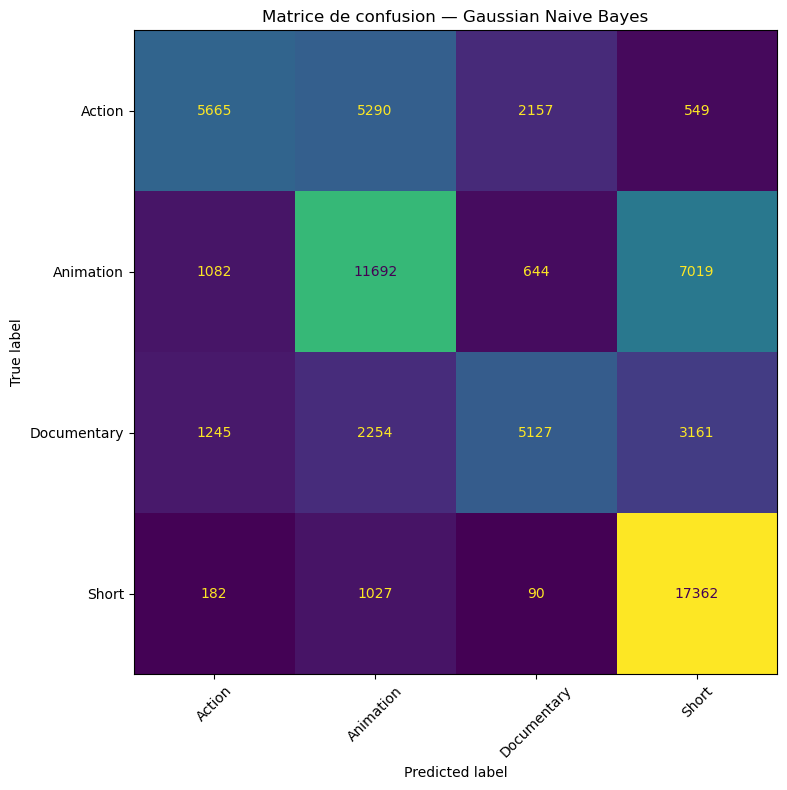

In [260]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matrice de confusion — Gaussian Naive Bayes")
plt.tight_layout()
plt.show()

## 6. Entraînement du Modèle 2 — Random Forest



### 6.1 Entraînement

In [261]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, n_jobs=-1, random_state=42)

### 6.2 Prédictions

In [262]:
y_pred_rf = rf_model.predict(X_test)

### 6.3 Evaluation globale

In [263]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)

print("Random Forest")
print(f"Accuracy        : {rf_accuracy:.4f}")
print(f"Precision macro : {rf_precision:.4f}")
print(f"Recall macro    : {rf_recall:.4f}")
print(f"F1-score macro  : {rf_f1:.4f}")

Random Forest
Accuracy        : 0.7857
Precision macro : 0.7927
Recall macro    : 0.7797
F1-score macro  : 0.7808


### 6.4 Rapport de classification détaillé

In [264]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

      Action       0.88      0.82      0.85     13661
   Animation       0.88      0.72      0.79     20437
 Documentary       0.70      0.68      0.69     11787
       Short       0.71      0.91      0.80     18661

    accuracy                           0.79     64546
   macro avg       0.79      0.78      0.78     64546
weighted avg       0.80      0.79      0.79     64546



### 6.5 Matrice de confusion

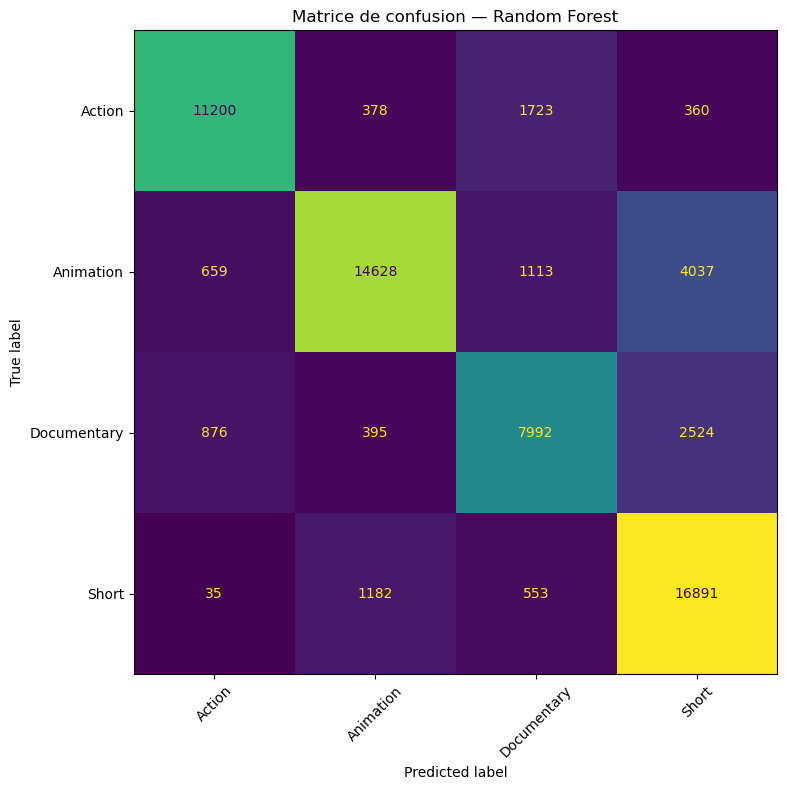

In [265]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matrice de confusion — Random Forest")
plt.tight_layout()
plt.show()

## 7. Entrainement du Modèle 3 — Gradient Boosting

### 7.1 Entrainement 

In [266]:
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

HistGradientBoostingClassifier(max_depth=10, max_iter=200, random_state=42)

### 7.2 Prédictions

In [267]:
y_pred_gb = gb_model.predict(X_test)

### 7.3 Evaluation

In [268]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, average="macro", zero_division=0)
gb_recall = recall_score(y_test, y_pred_gb, average="macro", zero_division=0)
gb_f1 = f1_score(y_test, y_pred_gb, average="macro", zero_division=0)

print("Gradient Boosting")
print(f"Accuracy        : {gb_accuracy:.4f}")
print(f"Precision macro : {gb_precision:.4f}")
print(f"Recall macro    : {gb_recall:.4f}")
print(f"F1-score macro  : {gb_f1:.4f}")

Gradient Boosting
Accuracy        : 0.7757
Precision macro : 0.7825
Recall macro    : 0.7644
F1-score macro  : 0.7678


### 7.4 Rapport détaillé

In [269]:
print(classification_report(
    y_test,
    y_pred_gb,
    target_names=target_names,
    zero_division=0
))

              precision    recall  f1-score   support

      Action       0.86      0.79      0.82     13661
   Animation       0.85      0.73      0.78     20437
 Documentary       0.72      0.63      0.67     11787
       Short       0.70      0.91      0.79     18661

    accuracy                           0.78     64546
   macro avg       0.78      0.76      0.77     64546
weighted avg       0.79      0.78      0.77     64546



### 7.5 Matrice de confusion

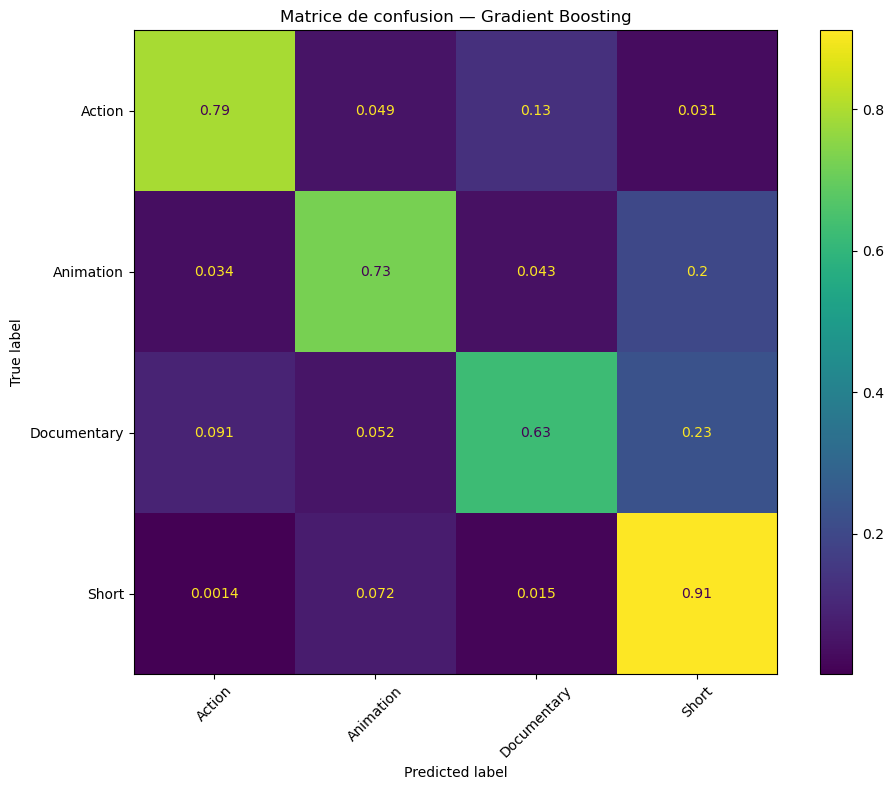

In [270]:
cm_gb = confusion_matrix(y_test, y_pred_gb, normalize="true")

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm_gb, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="viridis")
plt.title("Matrice de confusion — Gradient Boosting")
plt.tight_layout()
plt.show()

## 8. Comparaison rigoureuse des modèles


### 8.1 Tableau récapitulatif

In [271]:
comparison = pd.DataFrame({
    "Modèle": [
        "Gaussian Naive Bayes",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        nb_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision_macro": [
        nb_precision,
        rf_precision,
        gb_precision
    ],
    "Recall_macro": [
        nb_recall,
        rf_recall,
        gb_recall
    ],
    "F1_macro": [
        nb_f1,
        rf_f1,
        gb_f1
    ]
})

comparison.sort_values("F1_macro", ascending=False)

,Modèle,Accuracy,Precision_macro,Recall_macro,F1_macro
1,Random Forest,0.7857,0.7927,0.7797,0.7808
2,Gradient Boosting,0.7757,0.7825,0.7644,0.7678
0,Gaussian Naive Bayes,0.6173,0.6319,0.5880,0.5885


### 8.2 Visualisation simple

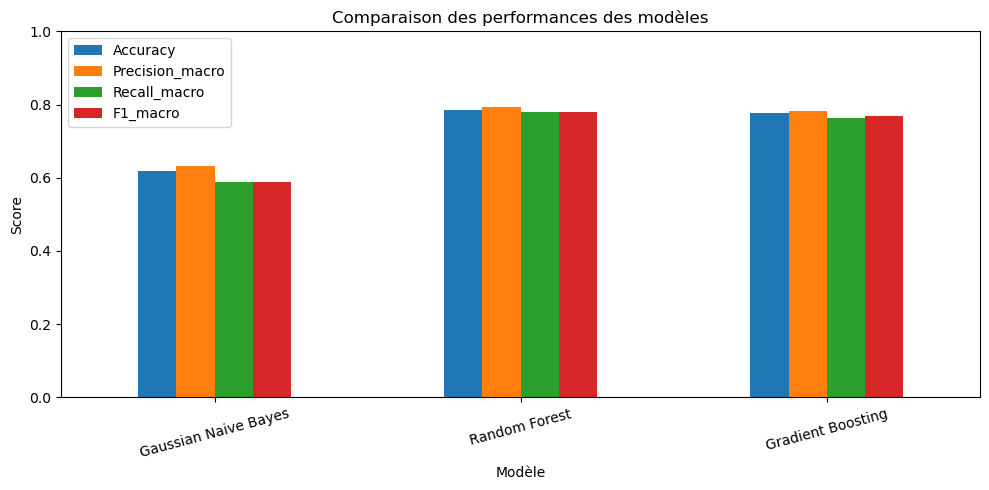

In [272]:
comparison_plot = comparison.set_index("Modèle")

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 9. Rapport de classification détaillé

Ce tableau permet d'évaluer les performances **genre par genre**.


In [273]:
target_names = label_mapping.sort_values("genre_encoded")["genre"].tolist()

report_dict = classification_report(
    y_test,
    y_pred_rf,   # ou y_pred_nb
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
Action,0.8771,0.8199,0.8475,"13,661.0000"
Animation,0.8821,0.7158,0.7903,"20,437.0000"
Documentary,0.7022,0.6780,0.6899,"11,787.0000"
Short,0.7093,0.9051,0.7954,"18,661.0000"
accuracy,0.7857,0.7857,0.7857,0.7857
macro avg,0.7927,0.7797,0.7808,"64,546.0000"
weighted avg,0.7982,0.7857,0.7855,"64,546.0000"


## 10. Lecture analytique des résultats

### Interprétation attendue
Dans ce projet, il est normal que les performances restent modérées, car :
1. les variables explicatives sont limitées à trois indicateurs numériques ;
2. ces variables ne décrivent pas directement le contenu narratif ou stylistique d'un film ;
3. certains genres peuvent partager des profils statistiques proches ;
4. Naive Bayes repose sur une hypothèse d'indépendance conditionnelle simplificatrice.

### Ce qu'il faudra expliquer dans le rapport
Une conclusion rigoureuse peut être formulée ainsi :

> Les résultats obtenus montrent que les variables numériques disponibles ne suffisent pas à discriminer parfaitement les genres de films. Le modèle parvient à capter certains profils statistiques, mais la prédiction du genre reste un problème complexe, car le genre dépend aussi d'éléments sémantiques, narratifs et contextuels absents des variables utilisées ici.

### Limites méthodologiques à mentionner
- simplification du genre à une seule étiquette principale ;
- exclusion des genres rares ;
- absence de variables textuelles comme `Overview` ;
- absence de variables supplémentaires comme une vraie mesure de popularité.


## 11. Sauvegarde du modèle et des résultats

On sauvegarde :
- le modèle entraîné ;
- les métriques principales ;
- le rapport de classification détaillé.


In [274]:
model_path = MODELS_DIR / "gaussian_nb_imdb_genre.joblib"
joblib.dump(nb_model, model_path)

print(f"Modèle sauvegardé : {model_path}")


metrics = {
    "accuracy": float(nb_accuracy),
    "precision_macro": float(nb_precision),
    "recall_macro": float(nb_recall),
    "f1_macro": float(nb_f1)
}

metrics_path = REPORTS_DIR / "gaussian_nb_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Métriques sauvegardées : {metrics_path}")
report_df.to_csv(REPORTS_DIR / "gaussian_nb_classification_report.csv")

print("Classification report sauvegardé")

Modèle sauvegardé : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\models\gaussian_nb_imdb_genre.joblib
Métriques sauvegardées : C:\Users\KenziLali\Desktop\projet-naive-bayes-imdb\reports\gaussian_nb_metrics.json
Classification report sauvegardé


## 12. Conclusion

Ce notebook a permis de :
- charger le dataset `processed` ;
- entraîner un modèle `GaussianNB` ;
- produire des prédictions sur un jeu de test ;
- mesurer les performances globales et détaillées ;
- sauvegarder le modèle et les principaux livrables.

La chaîne de travail est maintenant structurée en deux blocs distincts :
1. **préparation des données** ;
2. **entraînement / évaluation du modèle**.

C'est une organisation propre, professionnelle et reproductible pour un projet académique de machine learning.
